In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
import risk_kit as rk
import numpy as np
import pandas as pd

In [4]:
ind = rk.get_ind_returns()
er = rk.annualize_rets(ind['1996':'2000'], 12)
cov = ind['1996':'2000'].cov()

C:\Users\Yifei\anaconda_projects\Investment Management with Python and Machine Learning Specialization\risk_kit.py:53: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ind = pd.read_csv('data/ind30_m_vw_rets.csv',


In [6]:
l = ['Food', 'Beer', 'Smoke', 'Coal']
er[l]

Food     0.116799
Beer     0.141126
Smoke    0.107830
Coal     0.414689
dtype: float64

In [7]:
cov.loc[l, l]

,Food,Beer,Smoke,Coal
Food,0.002609,0.002379,0.002061,0.000027
Beer,0.002379,0.005264,0.001359,0.001728
Smoke,0.002061,0.001359,0.008349,-0.000733
Coal,0.000027,0.001728,-0.000733,0.018641


In [10]:
weights = np.repeat(1/4, 4)
weights

array([0.25, 0.25, 0.25, 0.25])

In [11]:
rk.portfolio_return(weights, er[l])

np.float64(0.19511097196038385)

In [12]:
rk.portfolio_vol(weights, cov.loc[l, l])

np.float64(0.055059195776437045)

## 2 Asset Frontier

In [13]:
l = ['Games', 'Fin']

In [14]:
n_points = 20
weights = [np.array([w, 1-w]) for w in np.linspace(0, 1, n_points)]
weights

[array([0., 1.]),
 array([0.05263158, 0.94736842]),
 array([0.10526316, 0.89473684]),
 array([0.15789474, 0.84210526]),
 array([0.21052632, 0.78947368]),
 array([0.26315789, 0.73684211]),
 array([0.31578947, 0.68421053]),
 array([0.36842105, 0.63157895]),
 array([0.42105263, 0.57894737]),
 array([0.47368421, 0.52631579]),
 array([0.52631579, 0.47368421]),
 array([0.57894737, 0.42105263]),
 array([0.63157895, 0.36842105]),
 array([0.68421053, 0.31578947]),
 array([0.73684211, 0.26315789]),
 array([0.78947368, 0.21052632]),
 array([0.84210526, 0.15789474]),
 array([0.89473684, 0.10526316]),
 array([0.94736842, 0.05263158]),
 array([1., 0.])]

In [15]:
len(weights)

20

In [16]:
l

['Games', 'Fin']

In [17]:
rets = [rk.portfolio_return(w, er[l]) for w in weights]
rets

[np.float64(0.22337143343356036),
 np.float64(0.21520512368930153),
 np.float64(0.20703881394504264),
 np.float64(0.19887250420078378),
 np.float64(0.19070619445652492),
 np.float64(0.18253988471226607),
 np.float64(0.17437357496800718),
 np.float64(0.16620726522374832),
 np.float64(0.15804095547948946),
 np.float64(0.14987464573523063),
 np.float64(0.14170833599097174),
 np.float64(0.13354202624671288),
 np.float64(0.12537571650245402),
 np.float64(0.11720940675819516),
 np.float64(0.1090430970139363),
 np.float64(0.10087678726967743),
 np.float64(0.09271047752541857),
 np.float64(0.08454416778115972),
 np.float64(0.07637785803690085),
 np.float64(0.06821154829264198)]

In [18]:
vols = [rk.portfolio_vol(w, cov.loc[l, l]) for w in weights]
vols

[np.float64(0.0630997295785121),
 np.float64(0.06184548206317773),
 np.float64(0.06069878923524834),
 np.float64(0.05966585256137839),
 np.float64(0.058752672223312284),
 np.float64(0.05796490842860514),
 np.float64(0.05730773341483651),
 np.float64(0.05678568123574939),
 np.float64(0.056402504039475894),
 np.float64(0.0561610444586889),
 np.float64(0.05606313362372235),
 np.float64(0.056109523015123265),
 np.float64(0.056299855936855894),
 np.float64(0.05663268109748638),
 np.float64(0.05710550711027121),
 np.float64(0.05771489323047962),
 np.float64(0.05845656886221488),
 np.float64(0.05932557264732352),
 np.float64(0.06031640142594411),
 np.float64(0.061423159933946626)]

In [22]:
ef = pd.DataFrame({'R': rets, 'Vol': vols})
ef

,R,Vol
0,0.223371,0.063100
1,0.215205,0.061845
2,0.207039,0.060699
3,0.198873,0.059666
4,0.190706,0.058753
5,0.182540,0.057965
6,0.174374,0.057308
7,0.166207,0.056786
8,0.158041,0.056403
9,0.149875,0.056161


<Axes: xlabel='Vol', ylabel='R'>

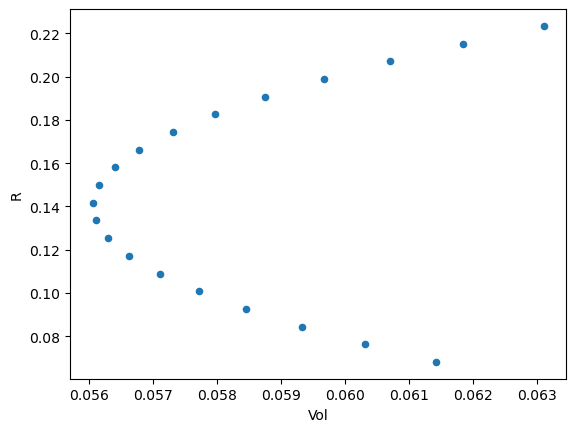

In [23]:
ef.plot.scatter(x = 'Vol', y = 'R')

<Axes: xlabel='Volatility'>

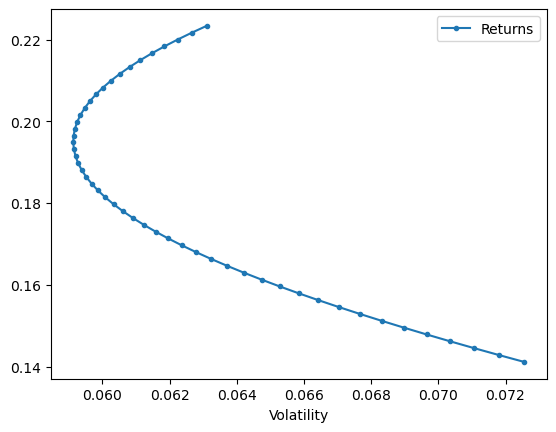

In [37]:
l = ['Fin', 'Beer']
rk.plot_ef2(50, er[l], cov.loc[l, l], style = '.-')